In [15]:
#1.Data loading and Preparation
import pandas as pd 

df = pd.read_csv("transactions.csv")


In [16]:
# Convert date column
df["order_date"] = pd.to_datetime(df["order_date"])

In [17]:
# Create revenue column
df["revenue"] = df["quantity"] * df["price"]

In [18]:
print(df.head())


   order_id customer_id order_date       product     category  quantity  \
0      1001        C001 2024-01-03  Coffee Maker   Appliances         1   
1      1002        C002 2024-01-05  Paper Towels    Household         3   
2      1003        C003 2024-01-08        Laptop  Electronics         1   
3      1004        C001 2024-01-15  Coffee Beans      Grocery         2   
4      1005        C004 2024-01-20    Desk Chair    Furniture         1   

   price  revenue  
0    120      120  
1      8       24  
2    950      950  
3     18       36  
4    210      210  


In [19]:
#2.Total Revenue
total_revenue = df["revenue"].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")


Total Revenue: $6,234.00


In [20]:
#3.Monthly Revenue Trend
df["month"] = df["order_date"].dt.to_period("M")

monthly_revenue = (
    df.groupby("month")["revenue"]
    .sum()
    .reset_index()
)

print(monthly_revenue)


     month  revenue
0  2024-01     1714
1  2024-02     1873
2  2024-03     2647


In [21]:
#4.Top Customers
customer_revenue = (
    df.groupby("customer_id")["revenue"]
    .sum()
    .reset_index()
    .sort_values(by="revenue", ascending=False)
)

top_customers = customer_revenue.head(10)
print(top_customers)


   customer_id  revenue
2         C003     1080
25        C026      950
7         C008      400
15        C016      400
0         C001      360
20        C021      300
6         C007      300
3         C004      290
10        C011      250
9         C010      220


In [11]:
#5.Repeat Purchase Rate
purchase_counts = (
    df.groupby("customer_id")["order_id"]
    .nunique()
    .reset_index()
)

repeat_customers = purchase_counts[
    purchase_counts["order_id"] > 1
]

repeat_rate = len(repeat_customers) / len(purchase_counts)

print(f"Repeat Purchase Rate: {repeat_rate:.2%}")


Repeat Purchase Rate: 22.22%


In [12]:
#6.Churn Risk Analysis
latest_date = df["order_date"].max()

recency = (
    df.groupby("customer_id")["order_date"]
    .max()
    .reset_index()
)

recency["days_since_last_purchase"] = (
    latest_date - recency["order_date"]
).dt.days

churn_risk = recency[recency["days_since_last_purchase"] > 90]

print(f"Customers at churn risk: {len(churn_risk)}")


Customers at churn risk: 0


In [14]:
import pandas as pd
import sqlite3

# Load dataset
df = pd.read_csv("transactions.csv")

# Create SQLite database
conn = sqlite3.connect("sales.db")

# Save table
df.to_sql("transactions", conn, if_exists="replace", index=False)

print("Database ready")


Database ready


In [22]:
#Top 5 Customers 
query = """
SELECT customer_id,
       SUM(quantity * price) AS total_revenue
FROM transactions
GROUP BY customer_id
ORDER BY total_revenue DESC
LIMIT 5;
"""

result = pd.read_sql(query, conn)
result


,customer_id,total_revenue
0,C003,1080
1,C026,950
2,C016,400
3,C008,400
4,C001,360


In [23]:
#Total Revenue
query = """
SELECT SUM(quantity * price) AS total_revenue
FROM transactions;
"""

result = pd.read_sql(query, conn)
result

,total_revenue
0,6234


In [25]:
#Monthly Revenue Trend
query = """
SELECT strftime('%Y-%m', order_date) AS month,
       SUM(quantity * price) AS revenue
FROM transactions
GROUP BY month
ORDER BY month;
"""

result = pd.read_sql(query, conn)
result

,month,revenue
0,None,6234


In [27]:
#Repeat Customer Identification
query = """
SELECT customer_id,
       COUNT(DISTINCT order_id) AS order_count
FROM transactions
GROUP BY customer_id
HAVING order_count > 1;
"""

result = pd.read_sql(query, conn)
result

,customer_id,order_count
0,C001,5
1,C002,4
2,C003,4
3,C004,2
4,C005,2
5,C006,2


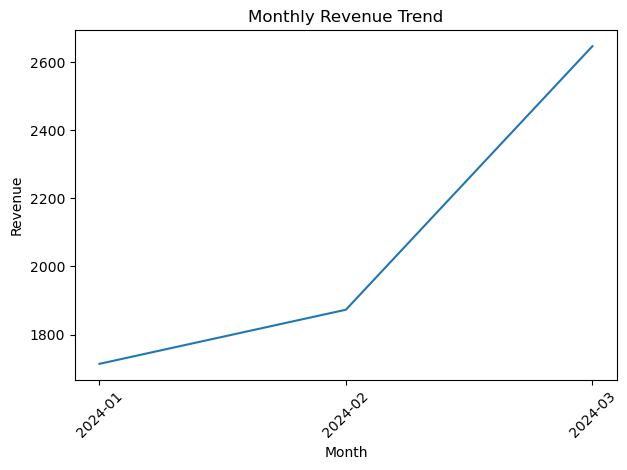

In [30]:
#Monthly Revenue Trend
import matplotlib.pyplot as plt

monthly_revenue["month"] = monthly_revenue["month"].astype(str)

plt.figure()
plt.plot(monthly_revenue["month"], monthly_revenue["revenue"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")
plt.tight_layout()
plt.show()

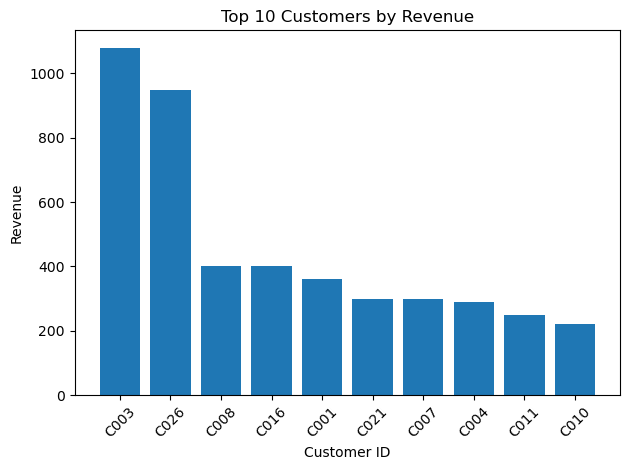

In [31]:
#Top 10 Customers by Revenue
plt.figure()
plt.bar(top_customers["customer_id"].astype(str),
        top_customers["revenue"])
plt.xticks(rotation=45)
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.title("Top 10 Customers by Revenue")
plt.tight_layout()
plt.show()

In [32]:
#Repeat vs One-Time Customers
one_time = len(purchase_counts[purchase_counts["order_id"] == 1])
repeat = len(purchase_counts[purchase_counts["order_id"] > 1])

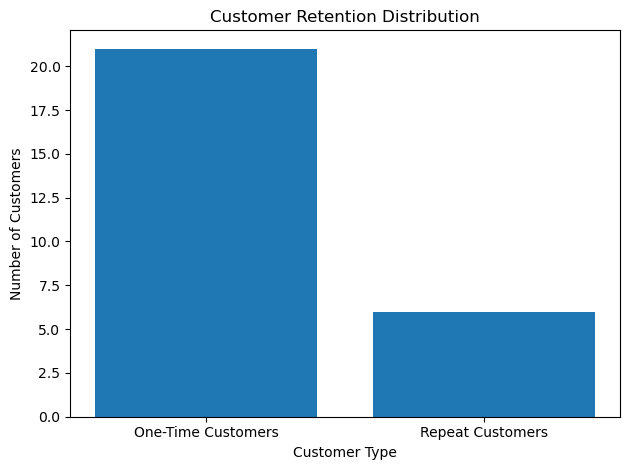

In [33]:
plt.figure()
plt.bar(["One-Time Customers", "Repeat Customers"],
        [one_time, repeat])
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.title("Customer Retention Distribution")
plt.tight_layout()
plt.show()

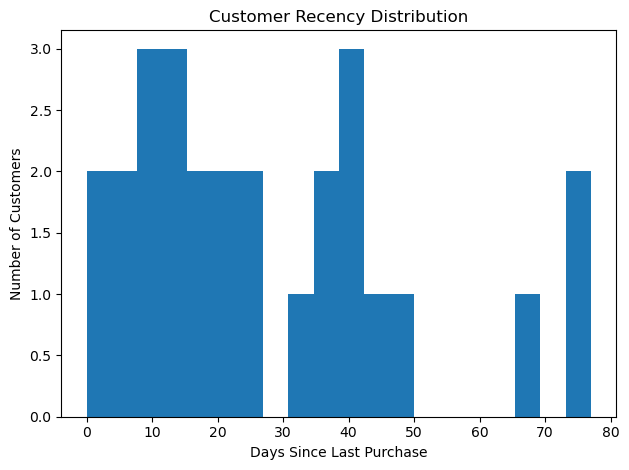

In [34]:
#Churn Risk Customers
plt.figure()
plt.hist(recency["days_since_last_purchase"], bins=20)
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")
plt.title("Customer Recency Distribution")
plt.tight_layout()
plt.show()